# 00 — Preprocessing & Splits (APTOS 2019)

Pipeline : **FOV crop → resize → split stratifie → export**

Trois decisions explicites :

1. **Pas de padding carre.** Le crop s'arrete a la bounding box du FOV. Les images
   APTOS ont des FOV majoritairement elliptiques (largeur > hauteur), donc le resize
   vers 512x512 introduit une legere anisotropie. C'est le compromis demande :
   zero pixel noir ajoute, au prix d'un facteur d'echelle x/y non identique.
   La cellule 6 quantifie cette distorsion pour pouvoir la justifier dans le memoire. `[IMPLEM]`

2. **Normalisation [-1, 1] appliquee au *chargement*, pas a l'export.** Stocker
   3662 images en float32 512x512x3 = ~11.5 Go, non telechargeable. On exporte en
   PNG uint8 (sans perte) et la normalisation `x/127.5 - 1.0` se fait dans le
   Dataset des notebooks 02-07. Le resultat numerique est strictement identique. `[IMPLEM]`

3. **Split stratifie au niveau image, pas patient.** APTOS 2019 ne publie qu'un
   `id_code` par image, sans identifiant patient ni indication oeil gauche/droit.
   Un split patient-level n'est donc pas derivable des labels fournis. On stratifie
   sur le grade pour preserver la distribution des 5 classes. `[INFERE]`


## 1. Configuration

In [1]:
# ---------------------------------------------------------------------------
# Chemins Kaggle par defaut (APTOS 2019 Blindness Detection)
# ---------------------------------------------------------------------------
RAW_DIR    = "/kaggle/input/competitions/aptos2019-blindness-detection"
TRAIN_CSV  = f"{RAW_DIR}/train.csv"
TRAIN_IMGS = f"{RAW_DIR}/train_images"

OUT_ROOT   = "/kaggle/working/aptos_preprocessed"

# ---------------------------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------------------------
IMG_SIZE   = 512          # cote de sortie (carre, obtenu par resize et non par padding)
FOV_TOL    = 7            # seuil d'intensite (0-255) separant le fond noir du FOV
MIN_AREA_R = 0.05         # une composante < 5% de l'image est du bruit, pas le FOV

# Interpolation : INTER_AREA pour le downscale (moyenne des pixels sources).
# Un INTER_LINEAR sous-echantillonne et efface les microanevrismes, qui font
# quelques pixels a la resolution native. `[IMPLEM]`
INTERP     = "area"

# ---------------------------------------------------------------------------
# Split
# ---------------------------------------------------------------------------
SEED       = 42
# Effectifs absolus plutot que fractions : une fraction arrondie par sklearn
# ne garantit pas un compte exact. 366 = taille du test de reference. `[IMPLEM]`
VAL_N      = 366
TEST_N     = 366          # => 2930 / 366 / 366 sur 3662 images (~80 / 10 / 10)

# ---------------------------------------------------------------------------
# Export
# ---------------------------------------------------------------------------
MAKE_ZIP   = True         # zip par split, pour telechargement depuis /kaggle/working


## 2. Imports

In [2]:
import os
import json
import shutil
import zipfile
from pathlib import Path
from typing import Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

np.random.seed(SEED)

CLASS_NAMES = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative DR"}

_INTERP_DISPATCH = {
    "area":   cv2.INTER_AREA,
    "linear": cv2.INTER_LINEAR,
    "cubic":  cv2.INTER_CUBIC,
    "lanczos": cv2.INTER_LANCZOS4,
}
INTERP_FLAG = _INTERP_DISPATCH[INTERP]

print("OpenCV", cv2.__version__)


OpenCV 4.13.0


## 3. Detection du FOV et crop

Le masque FOV est calcule sur l'image **brute**, avant toute transformation
d'intensite. Un rehaussement de contraste (CLAHE, soustraction de fond) remonte
le fond noir vers ~128 et rend le seuillage inoperant — l'ordre des operations
n'est donc pas interchangeable. `[IMPLEM]`

La bounding box est prise sur la **plus grande composante connexe** et non sur
l'ensemble des pixels au-dessus du seuil : les artefacts de bord (bandes
lumineuses, timestamps graves par certaines cameras) elargiraient sinon la box
bien au-dela du disque retinien.

In [3]:
def _fov_mask(bgr: np.ndarray, tol: int = FOV_TOL) -> np.ndarray:
    """Masque binaire du champ de vue (disque retinien), calcule sur l'image brute."""
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    # Flou median : neutralise les pixels chauds isoles du capteur qui, seuls,
    # creeraient de minuscules composantes parasites.
    gray = cv2.medianBlur(gray, 5)

    mask = (gray > tol).astype(np.uint8)

    # Fermeture : rebouche les trous internes (reflets speculaires sombres,
    # vaisseaux tres contrastes) pour que le FOV soit une seule composante pleine.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask


def _largest_component_bbox(mask: np.ndarray,
                            min_area_ratio: float = MIN_AREA_R) -> Optional[Tuple[int, int, int, int]]:
    """Bounding box (y0, y1, x0, x1) de la plus grande composante connexe du masque."""
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if n <= 1:                                  # aucun premier plan detecte
        return None

    # stats[0] est le fond : on l'exclut avant l'argmax.
    areas = stats[1:, cv2.CC_STAT_AREA]
    idx = int(np.argmax(areas)) + 1

    if stats[idx, cv2.CC_STAT_AREA] < min_area_ratio * mask.size:
        return None                             # composante trop petite pour etre un FOV

    x = stats[idx, cv2.CC_STAT_LEFT]
    y = stats[idx, cv2.CC_STAT_TOP]
    w = stats[idx, cv2.CC_STAT_WIDTH]
    h = stats[idx, cv2.CC_STAT_HEIGHT]
    return y, y + h, x, x + w


def crop_fov(bgr: np.ndarray, tol: int = FOV_TOL) -> Tuple[np.ndarray, bool]:
    """Recadre sur le FOV. Retourne (image, succes) ; l'image brute si echec."""
    box = _largest_component_bbox(_fov_mask(bgr, tol))
    if box is None:
        return bgr, False
    y0, y1, x0, x1 = box
    return bgr[y0:y1, x0:x1], True


def preprocess(bgr: np.ndarray, size: int = IMG_SIZE) -> Tuple[np.ndarray, dict]:
    """FOV crop -> resize direct vers (size, size). Aucun padding ajoute."""
    h0, w0 = bgr.shape[:2]
    cropped, ok = crop_fov(bgr)
    hc, wc = cropped.shape[:2]

    out = cv2.resize(cropped, (size, size), interpolation=INTERP_FLAG)

    meta = {
        "orig_h": h0, "orig_w": w0,
        "crop_h": hc, "crop_w": wc,
        "fov_ok": ok,
        # Rapport des facteurs d'echelle x et y : 1.0 = pas de distorsion.
        "aspect_distortion": round((size / wc) / (size / hc), 4),
    }
    return out, meta


## 4. Verification visuelle sur quelques cas

(3662, 2) {0: 1805, 1: 370, 2: 999, 3: 193, 4: 295}


/tmp/ipykernel_23/4152299377.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(1, random_state=SEED)))


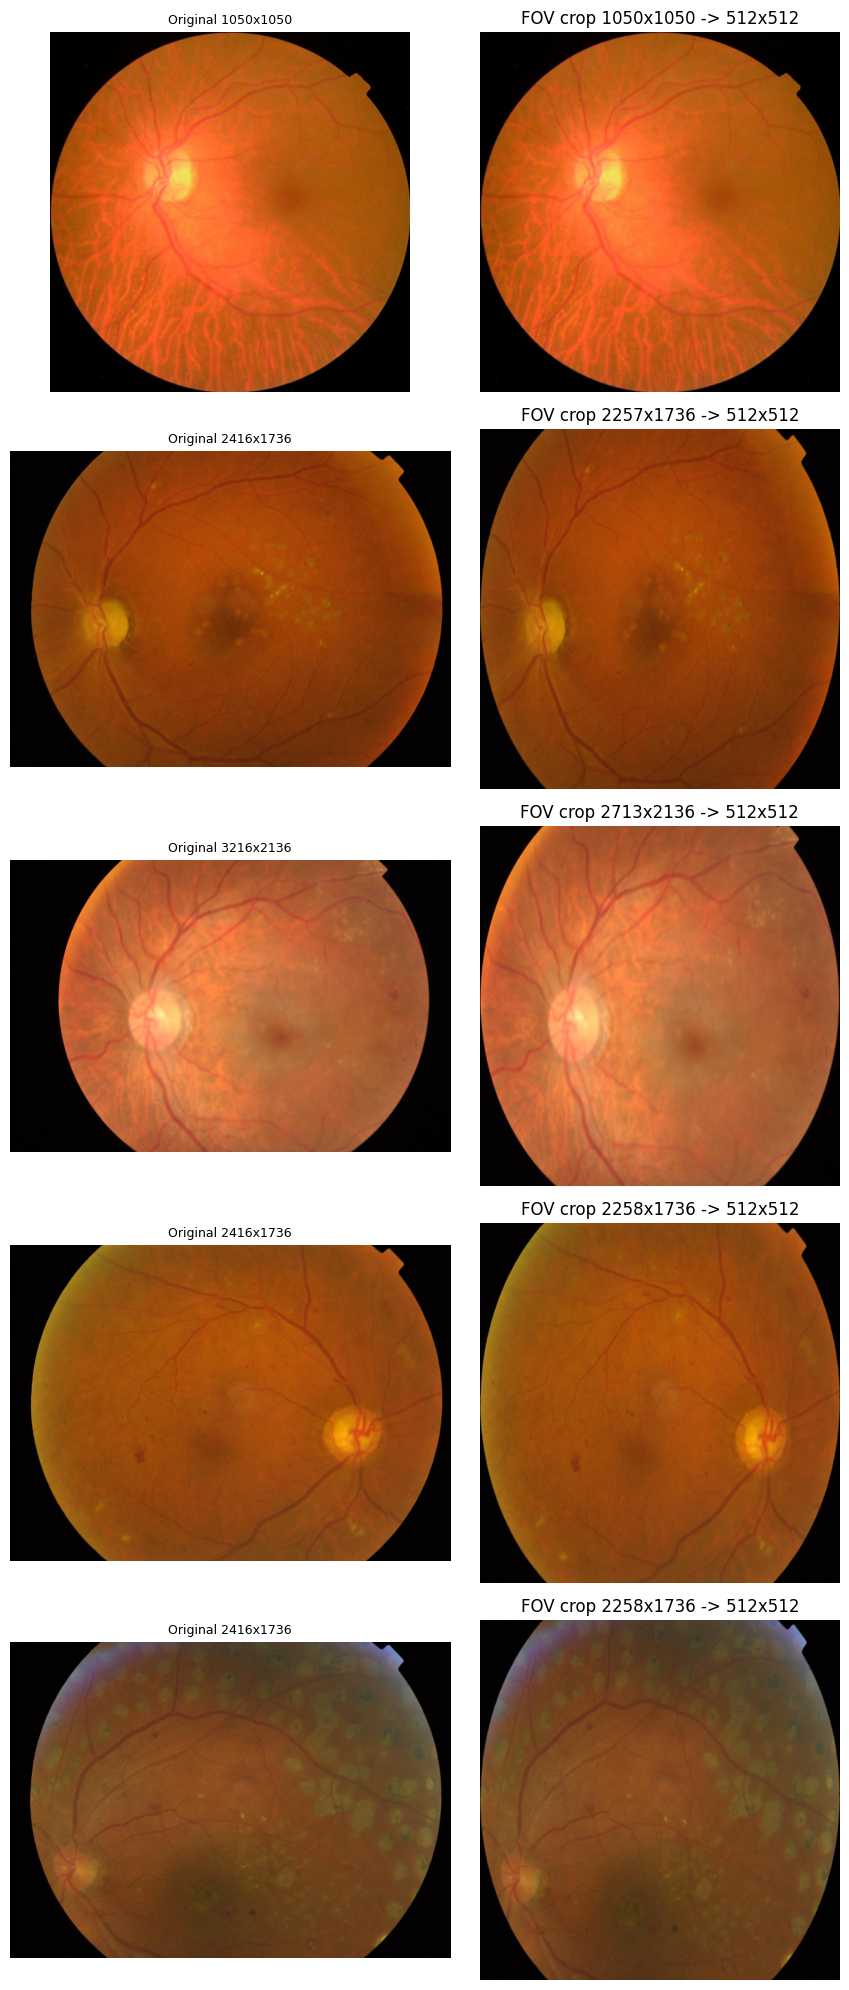

In [4]:
df = pd.read_csv(TRAIN_CSV)
print(df.shape, df["diagnosis"].value_counts().sort_index().to_dict())


def _read(id_code: str) -> np.ndarray:
    img = cv2.imread(f"{TRAIN_IMGS}/{id_code}.png")
    if img is None:
        raise FileNotFoundError(id_code)
    return img


# Un exemplaire de chaque grade, pour couvrir les differents formats de camera.
samples = (df.groupby("diagnosis", group_keys=False)
             .apply(lambda g: g.sample(1, random_state=SEED)))

fig, axes = plt.subplots(len(samples), 2, figsize=(9, 4 * len(samples)))
for ax_row, (_, row) in zip(axes, samples.iterrows()):
    raw = _read(row["id_code"])
    out, meta = preprocess(raw)

    ax_row[0].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
    ax_row[0].set_title(f"Original {meta['orig_w']}x{meta['orig_h']}", fontsize=9)
    ax_row[1].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    ax_row[1].set_title(
        f"FOV crop {meta['crop_w']}x{meta['crop_h']} -> {IMG_SIZE}x{IMG_SIZE}")

    for ax in ax_row:
        ax.axis("off")
    ax_row[0].set_ylabel(CLASS_NAMES[row["diagnosis"]])

plt.tight_layout()
plt.show()


## 5. Split stratifie

Deux `train_test_split` successifs avec des **effectifs entiers** : le premier
isole `VAL_N + TEST_N` images, le second coupe ce reliquat en `TEST_N` / `VAL_N`.
Passer des entiers (et non des fractions) garantit exactement 366 / 366.


In [5]:
strat = df["diagnosis"]

train_df, tmp_df = train_test_split(
    df, test_size=VAL_N + TEST_N, stratify=strat, random_state=SEED)

# test_size entier : sklearn l'interprete comme un nombre d'echantillons.
val_df, test_df = train_test_split(
    tmp_df, test_size=TEST_N, stratify=tmp_df["diagnosis"], random_state=SEED)

assert len(val_df) == VAL_N and len(test_df) == TEST_N, (len(val_df), len(test_df))

splits = {"train": train_df, "val": val_df, "test": test_df}

dist = pd.DataFrame({
    name: d["diagnosis"].value_counts(normalize=True).sort_index().round(4)
    for name, d in splits.items()
})
dist.loc["n"] = [len(d) for d in splits.values()]
print(dist)

# Garde-fou : aucun id_code ne doit apparaitre dans deux splits.
ids = [set(d["id_code"]) for d in splits.values()]
assert not (ids[0] & ids[1]) and not (ids[0] & ids[2]) and not (ids[1] & ids[2]), "fuite entre splits"
print("\nOK : splits disjoints")


               train       val      test
diagnosis                               
0             0.4928    0.4918    0.4945
1             0.1010    0.1011    0.1011
2             0.2727    0.2732    0.2732
3             0.0529    0.0519    0.0519
4             0.0805    0.0820    0.0792
n          2930.0000  366.0000  366.0000

OK : splits disjoints


## 6. Traitement par lot et export

Sortie en PNG uint8 (compression sans perte — un JPEG reintroduirait des
artefacts de blocs qui se confondent avec les microanevrismes). Arborescence :

```
aptos_preprocessed/
├── train/<id_code>.png
├── val/<id_code>.png
├── test/<id_code>.png
├── train.csv  val.csv  test.csv     # id_code, diagnosis, + meta de crop
└── preprocessing_config.json
```

In [6]:
def _process_split(name: str, split_df: pd.DataFrame, out_root: str) -> pd.DataFrame:
    """Traite et ecrit un split ; retourne le manifeste avec les metadonnees de crop."""
    out_dir = Path(out_root) / name
    out_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    for _, r in tqdm(split_df.iterrows(), total=len(split_df), desc=name):
        img, meta = preprocess(_read(r["id_code"]))
        cv2.imwrite(str(out_dir / f"{r['id_code']}.png"), img)
        rows.append({"id_code": r["id_code"], "diagnosis": int(r["diagnosis"]), **meta})

    man = pd.DataFrame(rows)
    man.to_csv(Path(out_root) / f"{name}.csv", index=False)
    return man


shutil.rmtree(OUT_ROOT, ignore_errors=True)
Path(OUT_ROOT).mkdir(parents=True, exist_ok=True)

manifests = {name: _process_split(name, d, OUT_ROOT) for name, d in splits.items()}

with open(Path(OUT_ROOT) / "preprocessing_config.json", "w") as f:
    json.dump({
        "img_size": IMG_SIZE, "fov_tol": FOV_TOL, "min_area_ratio": MIN_AREA_R,
        "interpolation": INTERP, "padding": "none",
        "normalization": "x/127.5 - 1.0 applied at load time, range [-1, 1]",
        "seed": SEED, "val_n": VAL_N, "test_n": TEST_N, "train_n": len(train_df),
        "split_level": "image (APTOS ne fournit pas d'identifiant patient)",
    }, f, indent=2)

all_man = pd.concat(manifests.values())
print("\nEchecs de detection FOV :", int((~all_man["fov_ok"]).sum()), "/", len(all_man))
print("Distorsion d'aspect  min/median/max : "
      f"{all_man['aspect_distortion'].min():.3f} / "
      f"{all_man['aspect_distortion'].median():.3f} / "
      f"{all_man['aspect_distortion'].max():.3f}")


train:   0%|          | 0/2930 [00:00<?, ?it/s]

val:   0%|          | 0/366 [00:00<?, ?it/s]

test:   0%|          | 0/366 [00:00<?, ?it/s]


Echecs de detection FOV : 0 / 3662
Distorsion d'aspect  min/median/max : 0.750 / 0.808 / 1.006


### Cas ou le FOV n'a pas ete detecte

Si `fov_ok == False`, l'image a ete redimensionnee sans crop. A inspecter :
soit l'image est deja recadree a ras du FOV (pas de fond noir a retirer, donc
comportement correct), soit elle est sur-exposee et le seuil `FOV_TOL` est a
remonter.

In [7]:
failed = all_man[~all_man["fov_ok"]]
print(f"{len(failed)} echec(s)")

if len(failed):
    show = failed.head(4)
    fig, axes = plt.subplots(1, len(show), figsize=(4 * len(show), 4))
    axes = np.atleast_1d(axes)
    for ax, (_, r) in zip(axes, show.iterrows()):
        ax.imshow(cv2.cvtColor(_read(r["id_code"]), cv2.COLOR_BGR2RGB))
        ax.set_title(f"{r['id_code']}\ngrade {r['diagnosis']}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


0 echec(s)


## 7. Controle qualite de la sortie

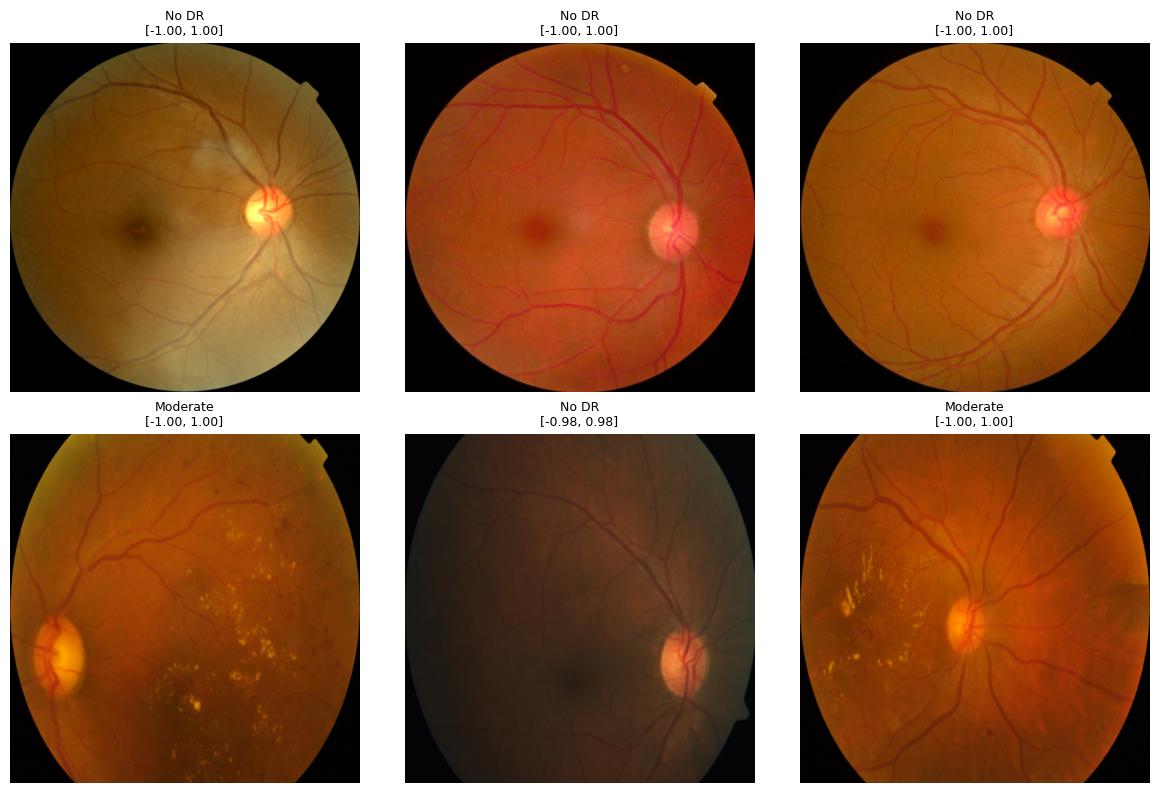

OK : dimensions et plage de normalisation conformes


In [8]:
# Verification que les images ecrites sont relisibles, a la bonne taille,
# et que la normalisation produit bien la plage attendue.
probe = manifests["train"].sample(6, random_state=SEED)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (_, r) in zip(axes.ravel(), probe.iterrows()):
    img = cv2.imread(f"{OUT_ROOT}/train/{r['id_code']}.png")
    assert img.shape == (IMG_SIZE, IMG_SIZE, 3), img.shape

    x = img.astype(np.float32) / 127.5 - 1.0
    assert -1.0 <= x.min() and x.max() <= 1.0

    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{CLASS_NAMES[r['diagnosis']]}\n[{x.min():.2f}, {x.max():.2f}]", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()
print("OK : dimensions et plage de normalisation conformes")


## 8. Archives pour telechargement

In [9]:
def _zip_dir(src: str, dst_zip: str) -> float:
    """Zippe un repertoire ; retourne la taille de l'archive en Mo."""
    with zipfile.ZipFile(dst_zip, "w", zipfile.ZIP_STORED) as z:
        # ZIP_STORED : les PNG sont deja compresses, redeflater coute du temps
        # CPU pour un gain nul.
        for p in sorted(Path(src).rglob("*")):
            if p.is_file():
                z.write(p, p.relative_to(Path(src).parent))
    return os.path.getsize(dst_zip) / 1e6


if MAKE_ZIP:
    for name in splits:
        mb = _zip_dir(f"{OUT_ROOT}/{name}", f"/kaggle/working/aptos_{name}_{IMG_SIZE}.zip")
        print(f"aptos_{name}_{IMG_SIZE}.zip : {mb:.1f} Mo")

# Les CSV et le config restent hors zip pour etre consultables directement.
for f in ["train.csv", "val.csv", "test.csv", "preprocessing_config.json"]:
    shutil.copy(f"{OUT_ROOT}/{f}", f"/kaggle/working/{f}")

print("\nFichiers dans /kaggle/working :")
for p in sorted(Path("/kaggle/working").glob("*")):
    if p.is_file():
        print(f"  {p.name}  ({p.stat().st_size / 1e6:.1f} Mo)")


aptos_train_512.zip : 879.8 Mo
aptos_val_512.zip : 109.4 Mo
aptos_test_512.zip : 110.6 Mo

Fichiers dans /kaggle/working :
  __notebook__.ipynb  (3.6 Mo)
  aptos_test_512.zip  (110.6 Mo)
  aptos_train_512.zip  (879.8 Mo)
  aptos_val_512.zip  (109.4 Mo)
  preprocessing_config.json  (0.0 Mo)
  test.csv  (0.0 Mo)
  train.csv  (0.1 Mo)
  val.csv  (0.0 Mo)


In [10]:
import os
import zipfile
from pathlib import Path

OUT_ROOT = "/kaggle/working/aptos_preprocessed"
ZIP_PATH = "/kaggle/working/aptos_preprocessed.zip"

def zip_dir(src: str, dst_zip: str):
    src_path = Path(src)

    print(f"Creating archive: {dst_zip}")
    print(f"Source: {src}")

    file_count = 0

    with zipfile.ZipFile(
        dst_zip,
        "w",
        compression=zipfile.ZIP_STORED
    ) as z:

        for p in sorted(src_path.rglob("*")):
            if p.is_file():
                # Keep the folder aptos_preprocessed inside the ZIP
                arcname = p.relative_to(src_path.parent)

                z.write(p, arcname)
                file_count += 1

                if file_count % 500 == 0:
                    print(f"  Added {file_count} files...")

    size_gb = os.path.getsize(dst_zip) / 1e9

    print("\n✓ ZIP created successfully")
    print(f"  Files: {file_count}")
    print(f"  Size: {size_gb:.2f} GB")
    print(f"  Path: {dst_zip}")

    return dst_zip


zip_dir(OUT_ROOT, ZIP_PATH)

Creating archive: /kaggle/working/aptos_preprocessed.zip
Source: /kaggle/working/aptos_preprocessed
  Added 500 files...
  Added 1000 files...
  Added 1500 files...
  Added 2000 files...
  Added 2500 files...
  Added 3000 files...
  Added 3500 files...

✓ ZIP created successfully
  Files: 3666
  Size: 1.10 GB
  Path: /kaggle/working/aptos_preprocessed.zip


'/kaggle/working/aptos_preprocessed.zip'

## 9. Chargement dans les notebooks 02-07

Republier `aptos_preprocessed/` en Kaggle Dataset, puis :

```python
class APTOSDataset(torch.utils.data.Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = cv2.imread(f"{self.img_dir}/{r.id_code}.png")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform is not None:              # augmentation train uniquement
            img = self.transform(image=img)["image"]

        # Normalisation [-1, 1]. Equivalent a Normalize(mean=.5, std=.5).
        x = torch.from_numpy(img.astype(np.float32) / 127.5 - 1.0).permute(2, 0, 1)
        return x, int(r.diagnosis)
```

Le crop FOV etant deja applique, les notebooks modeles n'ont plus qu'a gerer
l'augmentation et, pour les backbones a resolution fixe (ViT-B/16 et DeiT en
224x224), un resize final depuis 512.

**Une reserve a garder en tete pour la comparaison CNN/ViT :** la normalisation
[-1, 1] correspond a `mean=std=0.5`, alors que les poids ImageNet de timm
attendent les statistiques ImageNet. L'ecart est absorbe au fine-tuning, mais
il faut appliquer la meme convention aux six modeles pour que la comparaison
reste valide.